In [1]:
import os 
import numpy as np
import polars as pl
import pandas as pd

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, classification_report, confusion_matrix

import seaborn as sns

In [2]:
WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/07_deepchrome/'
DATASET_DIR = '../dataset/E066/'
OUTPUT_DIR = os.path.join(WORKING_DIR, 'output', 'logistic_regression', 'all_histone')

In [3]:
def load_data(path):
    gene_pl = pl.read_parquet(path)
    return gene_pl

In [4]:
def reformat_data(df, columns):
    processed_arrays = []

    for col in columns:
        arrays = df[col].to_list()
        stacked = np.vstack(arrays)
        processed_arrays.append(stacked)

    X = np.hstack(processed_arrays)
    return X

In [5]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

In [6]:
def plot_roc_curve(y_true, y_prob, title='ROC Curve'):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()
    
    return roc_auc

In [7]:
def create_and_train_model(X, y, random_state=42):
    # Split the dataset
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.666, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

    # Create and train the model
    model = MLPClassifier(
                hidden_layer_sizes=(256, 128, 64),  # Three hidden layers
                max_iter=1000,
                activation='relu',
                solver='adam',
                random_state=42,
                verbose=True
            )
    
    model.fit(X_train, y_train)

    # Get predictions and probabilities
    train_pred = model.predict(X_train)
    train_prob = model.predict_proba(X_train)[:, 1]
    
    val_pred = model.predict(X_val)
    val_prob = model.predict_proba(X_val)[:, 1]
    
    test_pred = model.predict(X_test)
    test_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    train_metrics = classification_report(y_train, train_pred)
    val_metrics = classification_report(y_val, val_pred)
    test_metrics = classification_report(y_test, test_pred)

    # Plot confusion matrices
    print("Train Set Confusion Matrix:")
    plot_confusion_matrix(y_train, train_pred, title='Train Set Confusion Matrix')
    
    print("\nValidation Set Confusion Matrix:")
    plot_confusion_matrix(y_val, val_pred, title='Validation Set Confusion Matrix')
    
    print("\nTest Set Confusion Matrix:")
    plot_confusion_matrix(y_test, test_pred, title='Test Set Confusion Matrix')
    
    # Plot ROC curves
    print("Train Set ROC Curve:")
    train_auc = plot_roc_curve(y_train, train_prob, title='Train Set ROC Curve')
    
    print("Validation Set ROC Curve:")
    val_auc = plot_roc_curve(y_val, val_prob, title='Validation Set ROC Curve')
    
    print("Test Set ROC Curve:")
    test_auc = plot_roc_curve(y_test, test_prob, title='Test Set ROC Curve')
    
    return model, {
        'train_metrics': test_metrics,
        'validation_metrics': val_metrics,
        'test_metrics': test_metrics,
        'train_auc': train_auc,
        'validation_auc': val_auc,
        'test_auc': test_auc,
        'splits': {
            'X_train': X_train,
            'X_val': X_val,
            'X_test': X_test,
            'y_train': y_train,
            'y_val': y_val,
            'y_test': y_test
        }
    }

In [8]:
# Load dataset
gene_pl = load_data(os.path.join(DATASET_DIR, 'E066_w_histone_pl.parquet'))
gene_pl.head(5)

gene_id,H3K4me3,H3K4me3_wc,H3K4me3_len,H3K4me1,H3K4me1_wc,H3K4me1_len,H3K36me3,H3K36me3_wc,H3K36me3_len,H3K9me3,H3K9me3_wc,H3K9me3_len,H3K27me3,H3K27me3_wc,H3K27me3_len,E066,label,all_histone
str,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,f64,i64,list[list[f64]]
"""ENSG00000000003""","[0.0, 4.19024, … 0.0]",19,100,"[0.0, 0.0, … 0.0]",9,100,"[3.39243, 0.0, … 0.0]",1,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,73.205,1,"[[0.0, 0.0, … 0.0], [0.0, 4.19024, … 0.0], … [3.39243, 0.0, … 0.0]]"
"""ENSG00000000005""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,0.191,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000000419""","[0.0, 0.0, … 0.0]",36,100,"[0.0, 0.0, … 0.0]",52,100,"[10.55422, 10.55422, … 0.0]",25,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,52.609,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [10.55422, 10.55422, … 0.0]]"
"""ENSG00000000457""","[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,4.733,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000000460""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[3.0104, 3.0104, … 0.0]",5,100,"[0.0, 0.0, … 0.0]",0,100,0.942,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"


In [9]:
markers = ['H3K4me3', 'H3K4me1', 'H3K36me3', 'H3K9me3', 'H3K27me3']

X = reformat_data(gene_pl, markers)

In [10]:
y = gene_pl['label'].to_numpy()

Iteration 1, loss = 0.60516744
Iteration 2, loss = 0.44123065
Iteration 3, loss = 0.39770403
Iteration 4, loss = 0.37238459
Iteration 5, loss = 0.34719110
Iteration 6, loss = 0.32048277
Iteration 7, loss = 0.29259620
Iteration 8, loss = 0.27010729
Iteration 9, loss = 0.24700556
Iteration 10, loss = 0.23360086
Iteration 11, loss = 0.22521596
Iteration 12, loss = 0.19001733
Iteration 13, loss = 0.18669295
Iteration 14, loss = 0.17812637
Iteration 15, loss = 0.17464762
Iteration 16, loss = 0.13759314
Iteration 17, loss = 0.11675774
Iteration 18, loss = 0.10172715
Iteration 19, loss = 0.10504772
Iteration 20, loss = 0.11822518
Iteration 21, loss = 0.10666576
Iteration 22, loss = 0.10049563
Iteration 23, loss = 0.09460155
Iteration 24, loss = 0.10293432
Iteration 25, loss = 0.09773009
Iteration 26, loss = 0.07961441
Iteration 27, loss = 0.08228705
Iteration 28, loss = 0.07411329
Iteration 29, loss = 0.08952749
Iteration 30, loss = 0.06971386
Iteration 31, loss = 0.06483751
Iteration 32, los

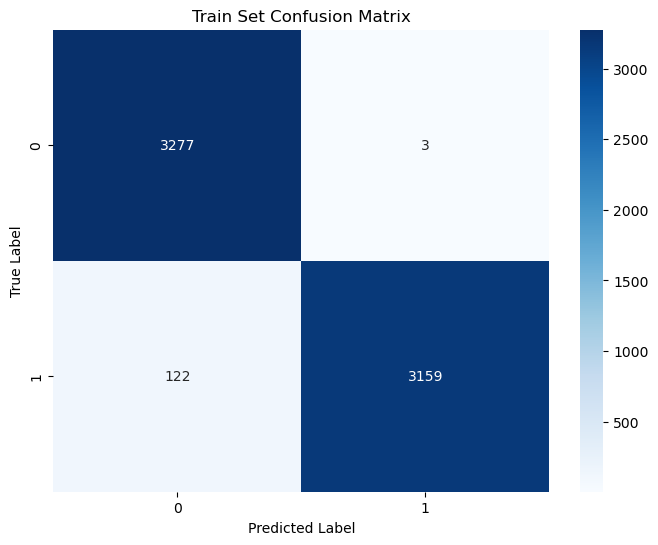


Validation Set Confusion Matrix:


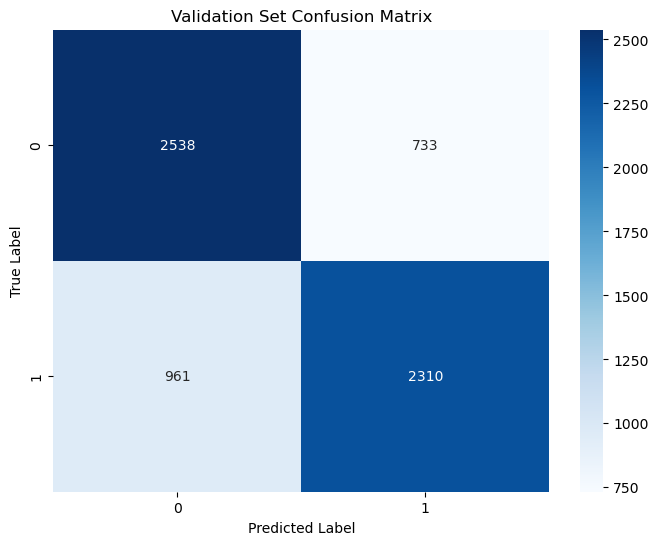


Test Set Confusion Matrix:


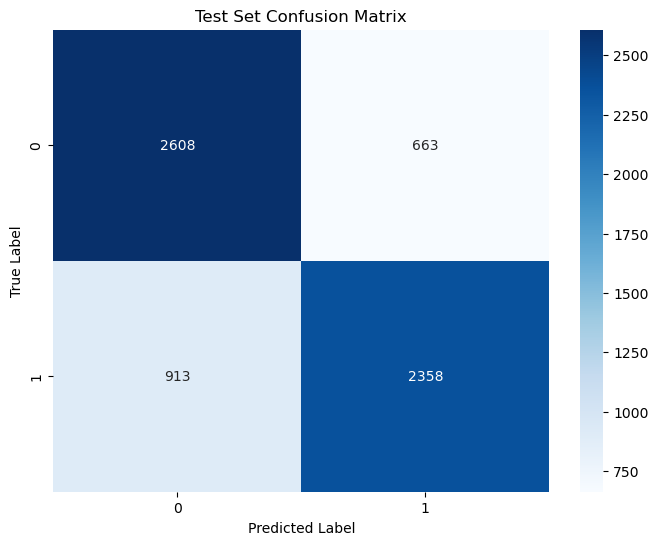

Train Set ROC Curve:


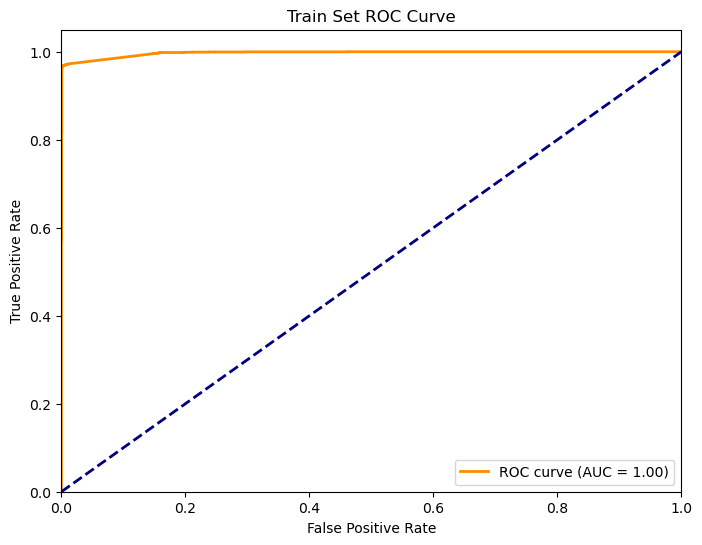

Validation Set ROC Curve:


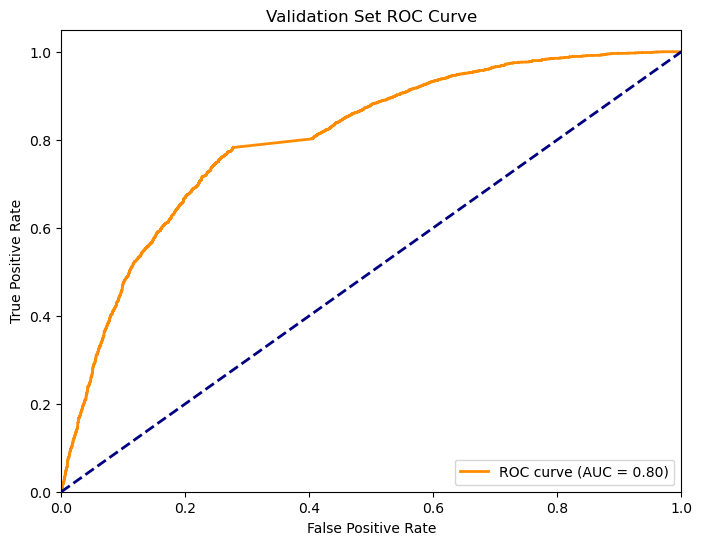

Test Set ROC Curve:


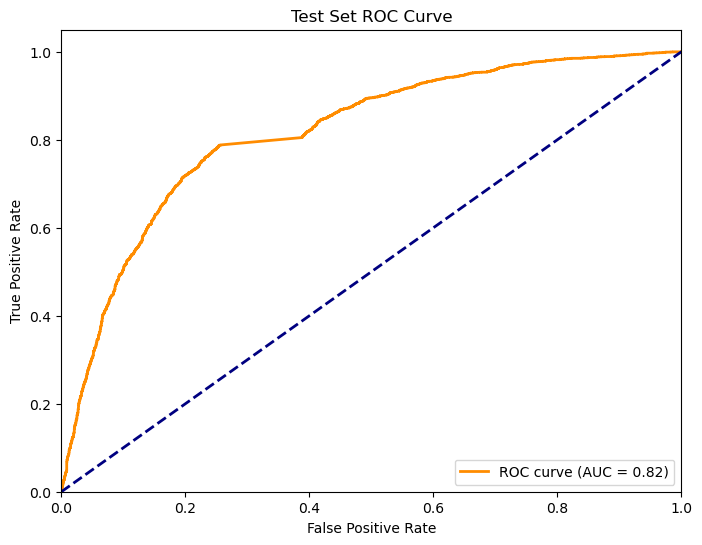

In [11]:
# Train and evaluate model
model, results = create_and_train_model(X, y)

In [12]:
# Print metrics
print("Train Set Metric:")
print(results['train_metrics'])
print("\nValidation Set Metrics:")
print(results['validation_metrics'])
print("\nTest Set Metrics:")
print(results['test_metrics'])
    
# Print AUC scores
print(f"Train Set AUC: {results['train_auc']:.3f}")
print(f"Validation Set AUC: {results['validation_auc']:.3f}")
print(f"Test Set AUC: {results['test_auc']:.3f}")

Train Set Metric:
              precision    recall  f1-score   support

           0       0.74      0.80      0.77      3271
           1       0.78      0.72      0.75      3271

    accuracy                           0.76      6542
   macro avg       0.76      0.76      0.76      6542
weighted avg       0.76      0.76      0.76      6542


Validation Set Metrics:
              precision    recall  f1-score   support

           0       0.73      0.78      0.75      3271
           1       0.76      0.71      0.73      3271

    accuracy                           0.74      6542
   macro avg       0.74      0.74      0.74      6542
weighted avg       0.74      0.74      0.74      6542


Test Set Metrics:
              precision    recall  f1-score   support

           0       0.74      0.80      0.77      3271
           1       0.78      0.72      0.75      3271

    accuracy                           0.76      6542
   macro avg       0.76      0.76      0.76      6542
weighted avg